# Capstone Project: Spotify Churn Analysis

**Overview**: In this problem, we will try to understand what causes churn in a Spotify customer to predict churn for future customers and take measures to prevent it.


### Notebook Overview - EDA

The goal of this notebook is to perform an exploration of the Spotify Churn dataset. By analyzing user demographics, listening habits, and subscription details, we aim to uncover the underlying patterns that differentiate a loyal user from one likely to churn.

#### Objectives of this phase

Check the Data: Look through the 8,000 rows of user information to make sure there are no missing pieces or obvious errors, check if there are any outliers using multiple methods such as z-score / IQR calculation.

Profile the Typical User: Create charts to see the "average" Spotify user in this dataset—looking at things like their age, how much music they listen to, and how often they skip songs.

Find Churn Patterns: Compare users who stayed versus users who left. Confirm the exact split between active and churned users.

### Getting Started

Our dataset comes from Kaggle (https://www.kaggle.com/datasets/nabihazahid/spotify-dataset-for-churn-analysis/data). 


### Understanding the Data

The dataset contains Spotify user information, including demographics, listening behavior, subscription type, and device usage, with the goal of predicting whether a user will churn or remain active. It is a synthetic dataset with 8000 rows and 12 features. Each row represents one customer's data.


### Read in the Data

Using pandas to read in the dataset `spotify_churn_dataset.csv` and assign to a meaningful variable name.

In [17]:
import pandas as pd

In [18]:
df = pd.read_csv('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/dataForFewerFeatures/spotify_churn_dataset.csv', sep = ',')

In [19]:
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


### Understanding the Features


Examining the data description below, and determinig if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
user_id → Unique identifier for each user

gender → User gender (Male/Female/Other)

age → User age

country → User location

subscription_type → Type of Spotify subscription (Free, Premium, Family, Student)

listening_time → Minutes spent listening per day

songs_played_per_day → Number of songs played daily

skip_rate → Percentage of songs skipped

device_type → Device used (Mobile, Desktop, Web)

ads_listened_per_week → Number of ads heard per week

offline_listening → Offline mode usage

Output variable (desired target):
is_churned → Target variable (0 = Active, 1 = Churned)
```



#### Create visualizations

In [21]:
# Create Visualization Folder
import os
import seaborn as sns
import matplotlib.pyplot as plt

# Create a dedicated folder for Capstone visualizations
viz_folder = '/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures'
if not os.path.exists(viz_folder):
    os.makedirs(viz_folder)

In [22]:
# Target Variable Count
def plot_target_distribution(df, target='is_churned'):
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target, palette='viridis', hue=target, legend=False)
    plt.title(f'Distribution of {target} (Target Variable)')
    plt.xlabel('Churn Status (0=Active, 1=Churned)')
    plt.ylabel('Count')
    
    # Save the plot
    save_path = os.path.join(viz_folder, 'target_distribution.png')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {save_path}")

In [23]:
# Categorical variables vs churn
def plot_categorical_vs_target(df, column, target='is_churned'):
    plt.figure(figsize=(10, 6))
    # Order by count for better readability
    order = df[column].value_counts().index
    sns.countplot(data=df, x=column, hue=target, palette='magma', order=order)
    
    plt.title(f'Churn Distribution by {column.replace("_", " ").title()}')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Save logic
    save_path = os.path.join(viz_folder, f'cat_{column}_vs_churn.png')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {save_path}")

In [24]:
# Numerical Outliers & Density
def plot_numeric_analysis(df, column, target='is_churned'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # KDE Plot: Shows the "shape" of data for Churn vs Active
    sns.kdeplot(data=df, x=column, hue=target, fill=True, ax=axes[0], palette='viridis')
    axes[0].set_title(f'{column.replace("_", " ").title()} Density')

    # Boxplot: Highlights Outliers clearly
    sns.boxplot(data=df, x=target, y=column, ax=axes[1], palette='viridis', hue=target, legend=False)
    axes[1].set_title(f'{column.replace("_", " ").title()} Outliers by Churn Status')
    
    plt.tight_layout()
    
    # Save logic
    save_path = os.path.join(viz_folder, f'num_{column}_analysis.png')
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {save_path}")

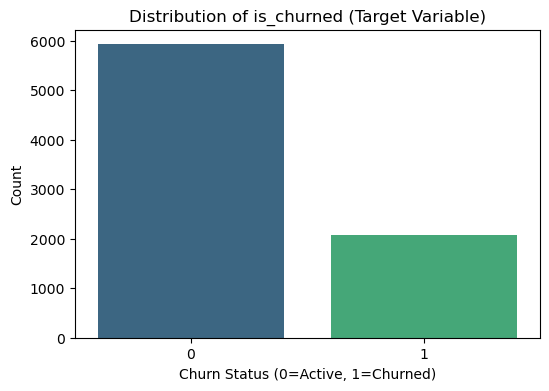

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/target_distribution.png
Processing 4 categorical columns...


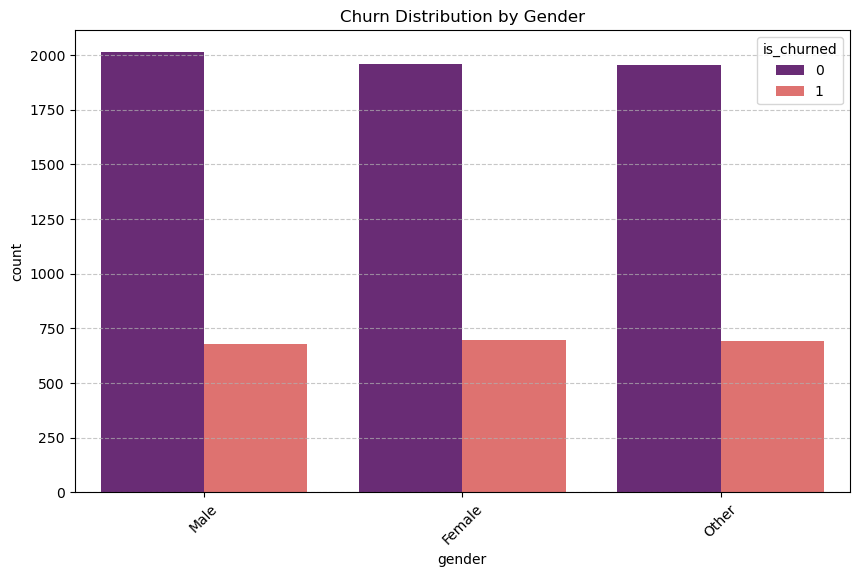

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/cat_gender_vs_churn.png


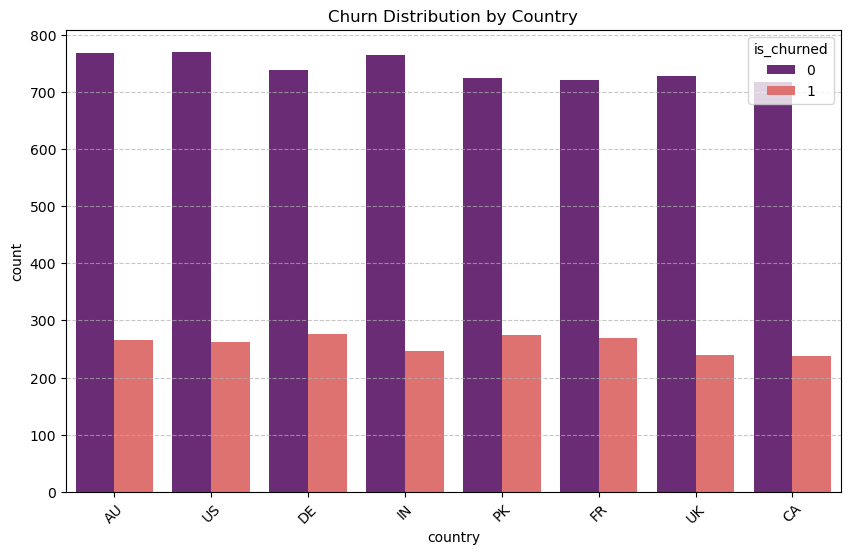

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/cat_country_vs_churn.png


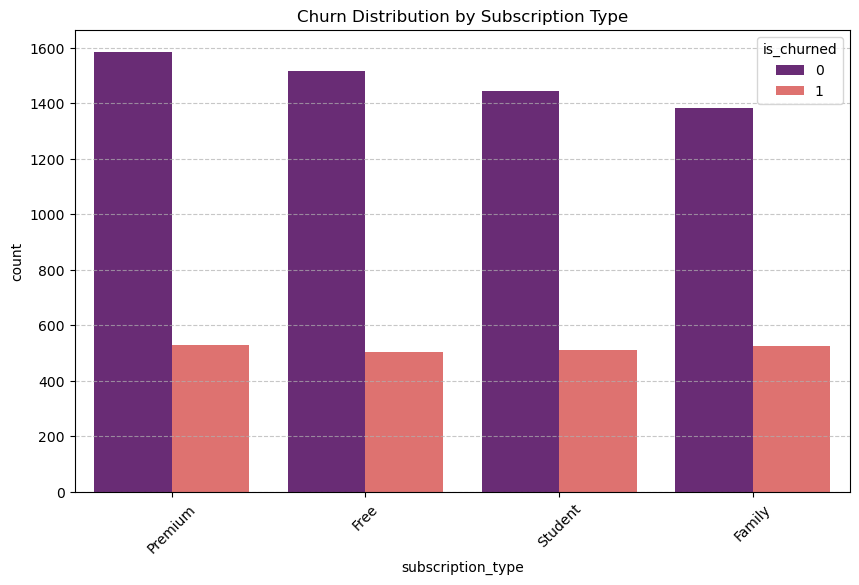

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/cat_subscription_type_vs_churn.png


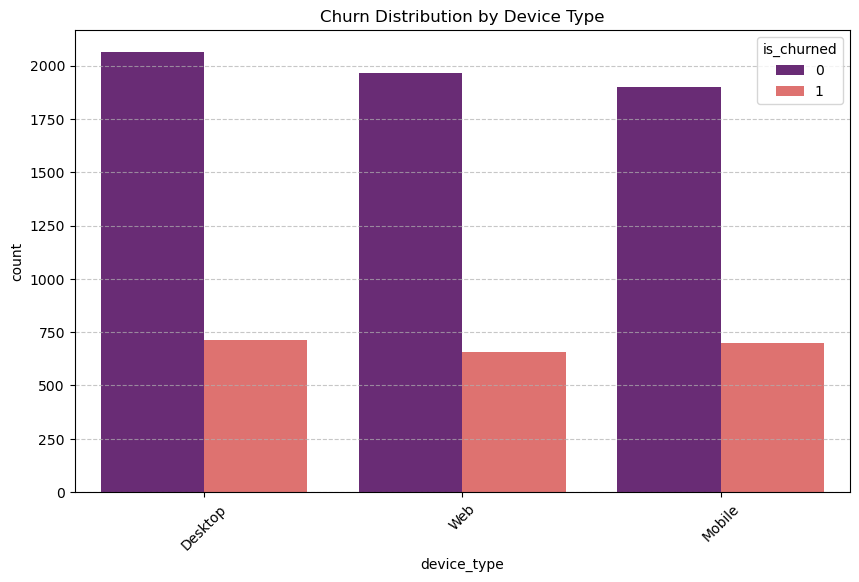

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/cat_device_type_vs_churn.png

Processing 7 numerical columns...


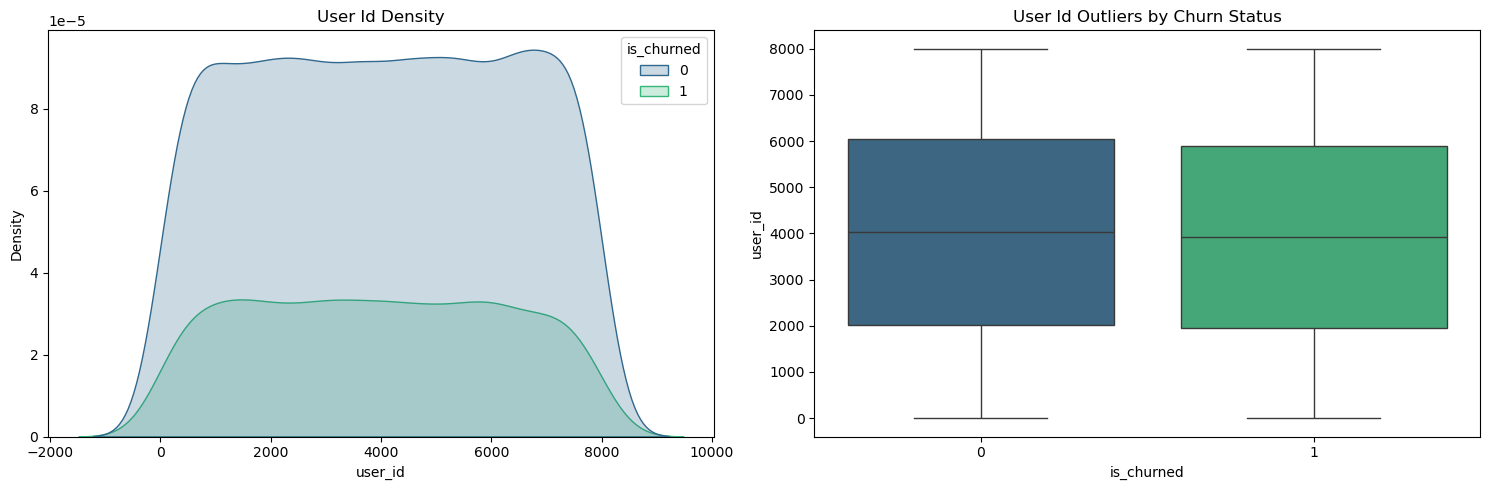

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/num_user_id_analysis.png


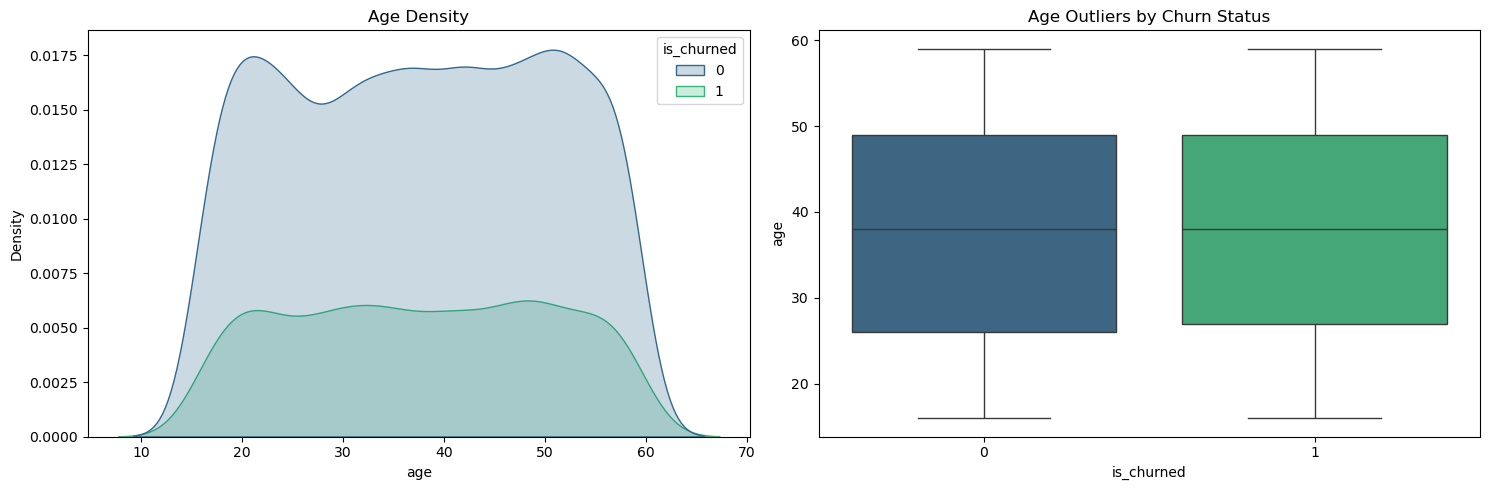

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/num_age_analysis.png


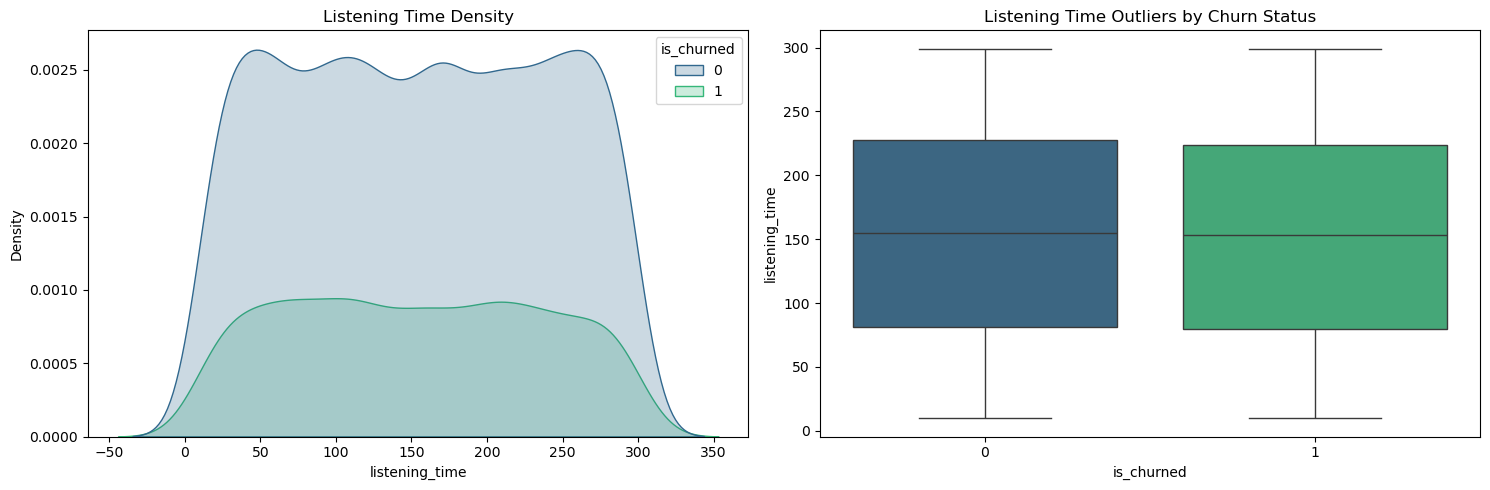

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/num_listening_time_analysis.png


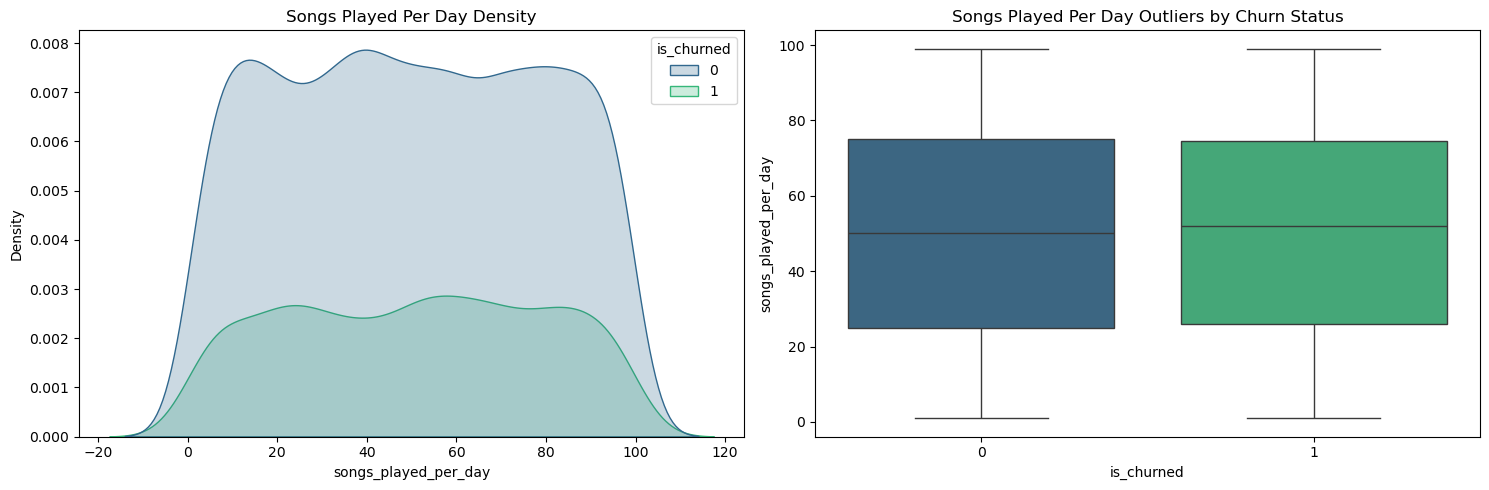

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/num_songs_played_per_day_analysis.png


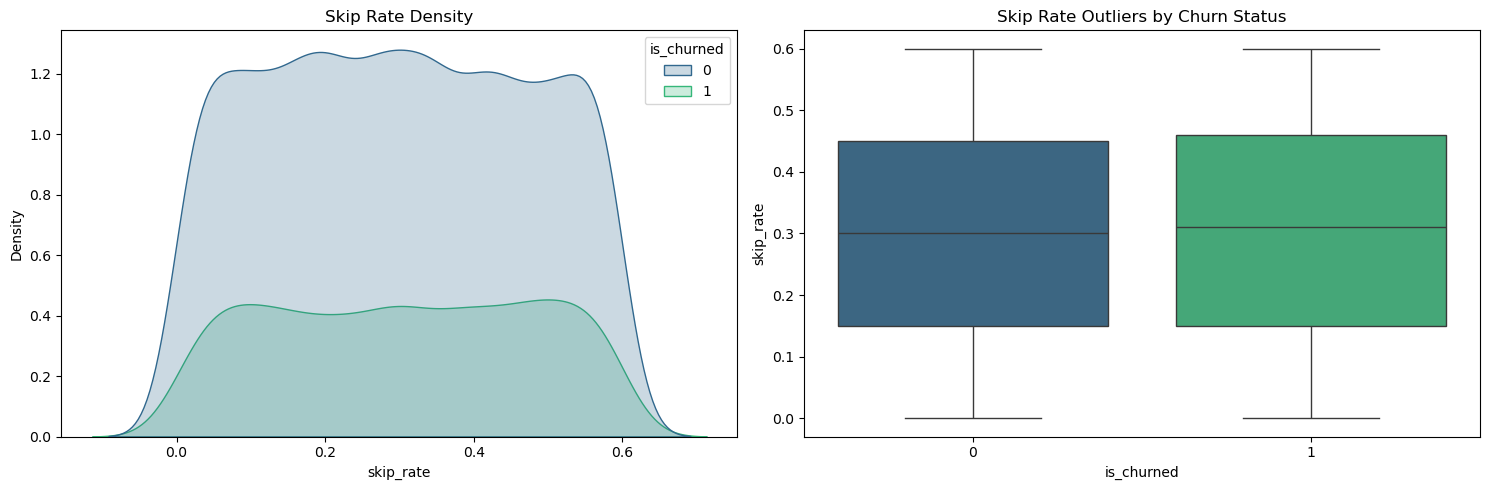

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/num_skip_rate_analysis.png


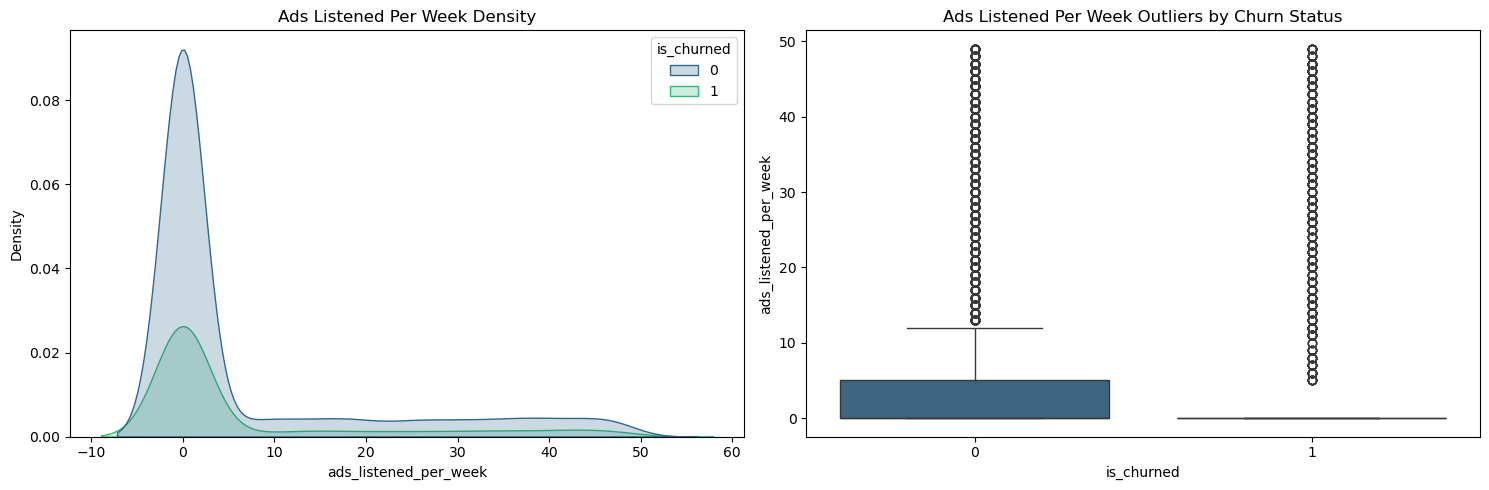

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/num_ads_listened_per_week_analysis.png


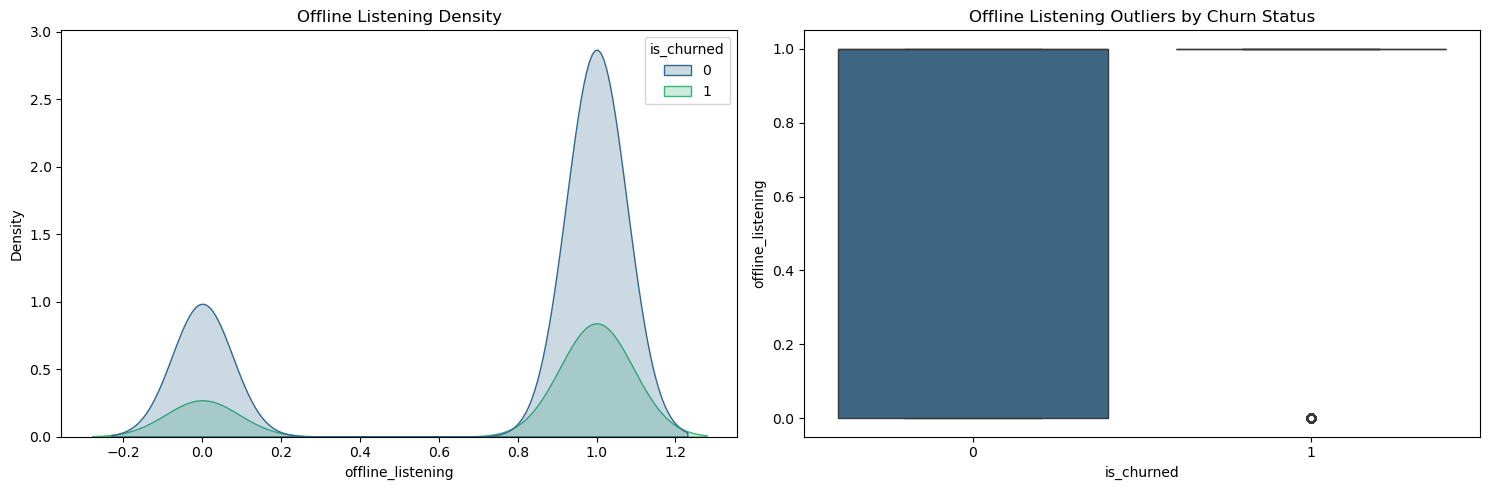

Saved: /Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/spotifyDataVisualizationsForFewerFeatures/num_offline_listening_analysis.png


In [25]:
# 1. Check target balance
plot_target_distribution(df)

# Separate columns by type automatically
# We exclude the target variable 'is_churned' from the features list
target_col = 'is_churned'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

# Remove target from numerical list if it exists there
if target_col in numerical_cols:
    numerical_cols.remove(target_col)

print(f"Processing {len(categorical_cols)} categorical columns...")
for col in categorical_cols:
    plot_categorical_vs_target(df, col)

print(f"\nProcessing {len(numerical_cols)} numerical columns...")
for col in numerical_cols:
    plot_numeric_analysis(df, col)

#### Check for nulls and unknowns, find outliers

In [26]:
# Checks for Nulls and 'Unknowns'

# 1. Standard Null Check
missing_data = df.isnull().sum().sort_values(ascending=False).to_frame(name='null_counts').reset_index()
print("Standard Null Values:")
print(missing_data)

# 2. Placeholder Check (Checking for 'unknown', 'none', or empty strings)
placeholders = ['unknown', 'None', 'none', ' ']
unknown_data = df.isin(placeholders).sum().sort_values(ascending=False).to_frame(name='unknown_counts').reset_index()
print("\nPlaceholder/Unknown Strings:")
print(unknown_data)

Standard Null Values:
                    index  null_counts
0                 user_id            0
1                  gender            0
2                     age            0
3                 country            0
4       subscription_type            0
5          listening_time            0
6    songs_played_per_day            0
7               skip_rate            0
8             device_type            0
9   ads_listened_per_week            0
10      offline_listening            0
11             is_churned            0

Placeholder/Unknown Strings:
                    index  unknown_counts
0                 user_id               0
1                  gender               0
2                     age               0
3                 country               0
4       subscription_type               0
5          listening_time               0
6    songs_played_per_day               0
7               skip_rate               0
8             device_type               0
9   ads_listened_per_

In [27]:
# Outlier Analysis using Z Score
from scipy import stats
import numpy as np

def z_score_outlier_analysis(df):
    # Select only numeric columns, excluding ID and Target
    numeric_cols = df.select_dtypes(include=['number']).drop(columns=['is_churned', 'user_id'], errors='ignore').columns
    
    z_report = []
    
    for col in numeric_cols:
        # Calculate absolute Z-scores
        z = np.abs(stats.zscore(df[col]))
        
        # Identify outliers (Threshold = 3)
        outlier_indices = np.where(z > 3)[0]
        count = len(outlier_indices)
        percentage = (count / len(df)) * 100
        
        z_report.append({
            'Column': col, 
            'Z-Score Outliers ( >3σ)': count, 
            'Percentage': f"{percentage:.2f}%"
        })
        
    return pd.DataFrame(z_report)

# Run the analysis
z_summary = z_score_outlier_analysis(df)
print(z_summary)

                  Column  Z-Score Outliers ( >3σ) Percentage
0                    age                        0      0.00%
1         listening_time                        0      0.00%
2   songs_played_per_day                        0      0.00%
3              skip_rate                        0      0.00%
4  ads_listened_per_week                       74      0.92%
5      offline_listening                        0      0.00%


In [28]:
# Mathematical Outlier Check (IQR Method)
numeric_cols = numeric_cols = df.select_dtypes(include=['number']).drop(columns=['is_churned', 'user_id'], errors='ignore').columns
outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count how many rows are outside these bounds
    count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outlier_counts[col] = count

print("Outlier Counts per Column:")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")

Outlier Counts per Column:
age: 0
listening_time: 0
songs_played_per_day: 0
skip_rate: 0
ads_listened_per_week: 1683
offline_listening: 0


### Findings

1. The data does not have null or unknown values so we do not have to handle them
2. z_score_outlier_analysis function showed that 0.92% of ads_listened_per_week data are outliers. This tells us these users are seeing a statistically extreme number of ads compared to the average user. The IQR check found 1,683 outliers in ads_listened_per_week. This is much higher than the Z-score count because IQR is more sensitive to "skewed" data—it catches values that are "unusual" even if they aren't "extreme" enough to hit a Z-score of 3.
3. There are ~ 3 times more active users compared to churned users.

### Understanding the Task

The goal of this project is to develop a predictive model that identifies Spotify users at high risk of churning. With approximately three times more active users than churned users, we will have to move beyond simple accuracy and measure the F1-Score. 

By identifying the specific behavioral triggers—such as high ad-to-music ratios or extreme skip rates—the business can deploy targeted retention offers to the 25% of the population currently identified as churn-prone.

In [29]:
# Save the data for the next notebook
df.to_parquet('/Users/Sucharitha/Desktop/Course/Modules/Module24/SpotifyChurnAnalysis/dataForFewerFeatures/spotify_eda_cleaned.parquet', index=False)

### A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [30]:
# Exact counts and percentages
print(df['is_churned'].value_counts())
print("\nPercentage split:")
print(df['is_churned'].value_counts(normalize=True) * 100)

is_churned
0    5929
1    2071
Name: count, dtype: int64

Percentage split:
is_churned
0    74.1125
1    25.8875
Name: proportion, dtype: float64
